# 03 — Inequality Analysis

For each of the 92 LMICs, this notebook:
1. Averages annual productivity loss rasters across a selected epoch
2. Clips and aligns population, RWI, and productivity loss to each country
3. Calculates the concentration index (CI) and quantile ratio
4. Generates concentration curve data
5. Saves results to `results/`

**Prerequisite:** run notebook 02 to generate the per-year productivity loss rasters.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import yaml
from tqdm import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from scripts.inequality import calculate_CI, calculate_concentration_curve, prepare_arrays
from scripts.raster_utils import get_country_geometry, align_rasters

with open(ROOT / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

DATA       = ROOT / 'data'
ANNUAL_DIR = DATA / 'processed' / 'annual'
RESULTS    = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

print('Ready.')

Ready.


## Configuration — select epoch

Set `EPOCH_START` and `EPOCH_END` to any years available in `data/processed/annual/`.

In [18]:
# --- Choose dataset and epoch ---
# Options: 'wbgt' | 'wbgt_baseline' | 'wbgt_future_2030_ssp245' | 'wbgt_future_2030_ssp585'
#          'wbgt_future_2050_ssp245' | 'wbgt_future_2050_ssp585'
DATASET = 'wbgt'

# wbgt_future_* variants share the wbgt_future config section
_cfg_key    = 'wbgt_future' if DATASET.startswith('wbgt_future') else DATASET
EPOCH_START = config[_cfg_key]['start_year']
EPOCH_END   = config[_cfg_key]['end_year']
# ---------------------------------

ANNUAL_DIR      = DATA / 'processed' / 'annual' / DATASET
POP_PATH        = str(ROOT / config['data']['population'])
RWI_PATH        = str(ROOT / config['data']['rwi'])
BOUNDARIES_PATH = str(ROOT / config['data']['boundaries'])
ISO_CODES       = config['iso_codes']

# Check which annual rasters exist for the epoch
annual_files = [
    ANNUAL_DIR / f'productivity_loss_{y}.tif'
    for y in range(EPOCH_START, EPOCH_END + 1)
    if (ANNUAL_DIR / f'productivity_loss_{y}.tif').exists()
]

print(f'Dataset:        {DATASET}')
print(f'Epoch:          {EPOCH_START}–{EPOCH_END}')
print(f'Annual rasters: {len(annual_files)} / {EPOCH_END - EPOCH_START + 1} years found')
print(f'Countries:      {len(ISO_CODES)}')

if not annual_files:
    raise FileNotFoundError(
        f'No annual rasters found in {ANNUAL_DIR} for {EPOCH_START}–{EPOCH_END}. '
        'Run notebook 02 first with the correct DATASET setting.'
    )

Dataset:        wbgt
Epoch:          1980–2025
Annual rasters: 46 / 46 years found
Countries:      92


## Build epoch-mean productivity loss raster (in memory)

In [19]:
# Read the first file to get grid shape and metadata
with rasterio.open(annual_files[0]) as src:
    ref_meta = src.meta.copy()
    shape = (src.height, src.width)

# Average annual rasters across all years in the epoch
accumulator = np.zeros(shape, dtype=np.float64)
valid_count = np.zeros(shape, dtype=np.int32)

for fpath in tqdm(annual_files, desc='Loading annual rasters'):
    with rasterio.open(fpath) as src:
        arr = src.read(1).astype(np.float64)
    valid = ~np.isnan(arr)
    accumulator[valid] += arr[valid]
    valid_count[valid] += 1

epoch_mean = np.where(valid_count > 0, accumulator / valid_count, np.nan).astype(np.float32)

print(f'Epoch mean loss range: {np.nanmin(epoch_mean):.4f} – {np.nanmax(epoch_mean):.4f}')
print(f'Mean (valid cells):    {np.nanmean(epoch_mean):.4f}')

# Save epoch-mean raster (dataset name in filename to avoid collisions)
epoch_risk_path = DATA / 'processed' / f'epoch_mean_{DATASET}_{EPOCH_START}_{EPOCH_END}.tif'
ref_meta.update(dtype='float32', nodata=np.nan)
with rasterio.open(epoch_risk_path, 'w', **ref_meta) as dst:
    dst.write(epoch_mean, 1)
print(f'Epoch raster saved: {epoch_risk_path}')

Loading annual rasters: 100%|██████████████████████████████████████████████████████████| 46/46 [02:05<00:00,  2.74s/it]


Epoch mean loss range: 0.0000 – 0.3804
Mean (valid cells):    0.0077
Epoch raster saved: E:\Projects\Howden\Heatwaves\howden_heat\data\processed\epoch_mean_wbgt_1980_2025.tif


## Run inequality analysis for all countries

In [20]:
ci_results = []
curve_records = []

for iso in tqdm(ISO_CODES, desc='Countries'):
    try:
        geom = get_country_geometry(BOUNDARIES_PATH, iso)
        pop, rwi, risk = align_rasters(POP_PATH, RWI_PATH, str(epoch_risk_path), geom)

        arrays = prepare_arrays(pop, rwi, risk)
        if arrays is None:
            print(f'  {iso}: insufficient valid data — skipping')
            continue
        pop_f, rwi_f, risk_f = arrays

        ci = calculate_CI(pop_f, rwi_f, risk_f)
        mean_loss = float(np.average(risk_f, weights=pop_f))
        total_pop = float(pop_f.sum())
        pop_coverage = float(pop_f.sum() / np.nansum(pop))

        ci_results.append({
            'iso3': iso,
            'epoch_start': EPOCH_START,
            'epoch_end': EPOCH_END,
            'CI': ci,
            'mean_productivity_loss': mean_loss,
            'total_population': total_pop,
            'rwi_coverage': pop_coverage,
            'n_cells': len(pop_f),
        })

        cum_pop, cum_risk = calculate_concentration_curve(pop_f, rwi_f, risk_f)
        for cp, cr in zip(cum_pop, cum_risk):
            curve_records.append({'iso3': iso, 'cum_pop_share': cp, 'cum_risk_share': cr})

    except Exception as e:
        print(f'  {iso}: ERROR — {e}')

ci_df = pd.DataFrame(ci_results)
curves_df = pd.DataFrame(curve_records)

print(f'\nCompleted: {len(ci_df)} / {len(ISO_CODES)} countries')
ci_df.sort_values('CI').head(10)

Countries: 100%|███████████████████████████████████████████████████████████████████████| 92/92 [04:13<00:00,  2.76s/it]


Completed: 92 / 92 countries


,iso3,epoch_start,epoch_end,CI,mean_productivity_loss,total_population,rwi_coverage,n_cells
21,CRI,1980,2025,-0.476695,0.030533,4904794.5,0.956376,27906
91,ZWE,1980,2025,-0.380370,0.004124,16137116.0,0.961278,237383
34,GTM,1980,2025,-0.258479,0.020788,18066740.0,0.974538,72396
89,ZAF,1980,2025,-0.257678,0.002423,59239852.0,0.921790,210847
73,SLV,1980,2025,-0.214463,0.042962,6222145.0,0.981669,20906
90,ZMB,1980,2025,-0.206798,0.002740,19661492.0,0.910162,208014
58,MRT,1980,2025,-0.193274,0.100903,4402656.0,0.838986,27168
66,PER,1980,2025,-0.191952,0.012978,32646822.0,0.949980,200381
42,KAZ,1980,2025,-0.189197,0.001784,19333208.0,0.932892,73534
3,ARM,1980,2025,-0.187404,0.000116,2882809.5,0.972516,8794


## Save results

In [21]:
ci_out     = RESULTS / f'inequality_results_{DATASET}_{EPOCH_START}_{EPOCH_END}.csv'
curves_out = RESULTS / f'concentration_curves_{DATASET}_{EPOCH_START}_{EPOCH_END}.csv'

ci_df.to_csv(ci_out, index=False)
curves_df.to_csv(curves_out, index=False)

print(f'Saved:\n  {ci_out}\n  {curves_out}')

Saved:
  E:\Projects\Howden\Heatwaves\howden_heat\results\inequality_results_wbgt_1980_2025.csv
  E:\Projects\Howden\Heatwaves\howden_heat\results\concentration_curves_wbgt_1980_2025.csv


## Quick summary

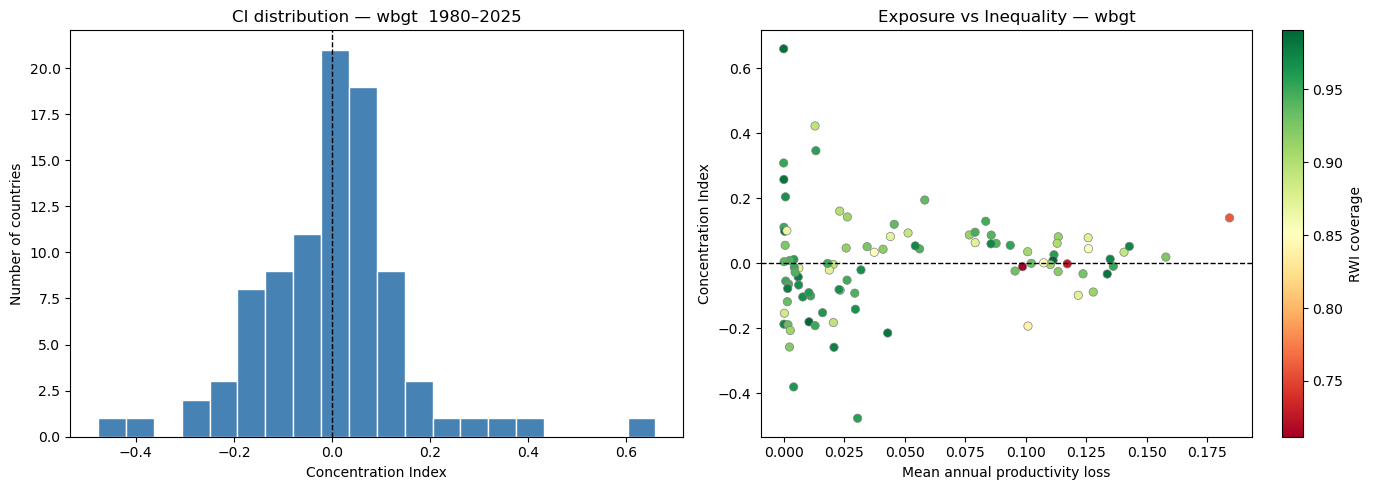

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(ci_df['CI'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Concentration Index')
ax.set_ylabel('Number of countries')
ax.set_title(f'CI distribution — {DATASET}  {EPOCH_START}–{EPOCH_END}')

ax = axes[1]
sc = ax.scatter(ci_df['mean_productivity_loss'], ci_df['CI'],
                c=ci_df['rwi_coverage'], cmap='RdYlGn', edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='RWI coverage')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Mean annual productivity loss')
ax.set_ylabel('Concentration Index')
ax.set_title(f'Exposure vs Inequality — {DATASET}')

plt.tight_layout()
plt.show()